In [2]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering
from sentence_transformers import SentenceTransformer

# Evaluation metrics
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage


# Coherence calculation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [7]:
df = pd.read_csv('/Users/aanchala/Task4/data/complete_preprocessing_final (1).csv')

print("="*70)
print("Data Summary")
print("="*70)
print(f"Total tickets: {len(df):,}")
print(f"Average ticket length: {df['word_count_final'].mean():.2f} words")
print(f"Text column: 'trunc_processed_text'")

print("\nSample tickets:")
for i in range(3):
    sample_text = df['trunc_processed_text'].iloc[i]
    print(f"{i+1}. {sample_text[:100]}...")

Data Summary
Total tickets: 27,919
Average ticket length: 29.31 words
Text column: 'trunc_processed_text'

Sample tickets:
1. write report significant problem centralize account management portal currently appear offline outag...
2. reach reach request detail information capability smart home integration product list website potent...
3. find reach request clarification bill payment procedure link account recently observe inconsistency ...


In [8]:
print("\n" + "="*70)
print("Generating Sentence Embeddings")
print("="*70)
print("Model: all-MiniLM-L6-v2")
print("This process may take 3-5 minutes...")

# Load pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
X_embeddings = model.encode(
    df['trunc_processed_text'].tolist(),
    show_progress_bar=True,
    batch_size=64,
    convert_to_numpy=True
)

print(f"\nEmbeddings generated successfully")
print(f"Shape: {X_embeddings.shape}")
print(f"Dimensions: {X_embeddings.shape[1]}")
print(f"Memory: {X_embeddings.nbytes / 1024 / 1024:.1f} MB")


Generating Sentence Embeddings
Model: all-MiniLM-L6-v2
This process may take 3-5 minutes...


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
print("\n" + "="*70)
print("K-Means Clustering")
print("="*70)
print("Configuration: k=5, seed=42")

# Initialize K-means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10,
    max_iter=300,
    algorithm='lloyd'
)

# Fit and predict
kmeans_labels = kmeans.fit_predict(X_embeddings)

# Calculate metrics
kmeans_silhouette = silhouette_score(X_embeddings, kmeans_labels)
kmeans_inertia = kmeans.inertia_
kmeans_cluster_sizes = Counter(kmeans_labels)

print("\nK-Means Results:")
print(f"  Silhouette score: {kmeans_silhouette:.4f}")
print(f"  Inertia: {kmeans_inertia:.2f}")
print(f"  Cluster distribution:")
for cluster_id in sorted(kmeans_cluster_sizes.keys()):
    count = kmeans_cluster_sizes[cluster_id]
    percentage = (count / len(df)) * 100
    print(f"    Cluster {cluster_id}: {count:,} tickets ({percentage:.1f}%)")


K-Means Clustering
Configuration: k=5, seed=42

K-Means Results:
  Silhouette score: 0.1214
  Inertia: 15136.99
  Cluster distribution:
    Cluster 0: 5,985 tickets (21.4%)
    Cluster 1: 3,999 tickets (14.3%)
    Cluster 2: 3,910 tickets (14.0%)
    Cluster 3: 3,861 tickets (13.8%)
    Cluster 4: 10,164 tickets (36.4%)


In [ ]:
print("\n" + "="*70)
print("Hierarchical Agglomerative Clustering")
print("="*70)
print("Configuration: k=5, Ward linkage")

# Run HAC
hac = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward',
    metric='euclidean'
)

hac_labels = hac.fit_predict(X_embeddings)

# Calculate metrics
hac_silhouette = silhouette_score(X_embeddings, hac_labels)
hac_cluster_sizes = Counter(hac_labels)

print("\nHAC Results:")
print(f"  Silhouette score: {hac_silhouette:.4f}")
print(f"  Cluster distribution:")
for cluster_id in sorted(hac_cluster_sizes.keys()):
    count = hac_cluster_sizes[cluster_id]
    percentage = (count / len(df)) * 100
    print(f"    Cluster {cluster_id}: {count:,} tickets ({percentage:.1f}%)")


Hierarchical Agglomerative Clustering
Configuration: k=5, Ward linkage

HAC Results:
  Silhouette score: 0.0970
  Cluster distribution:
    Cluster 0: 11,589 tickets (41.5%)
    Cluster 1: 6,345 tickets (22.7%)
    Cluster 2: 4,682 tickets (16.8%)
    Cluster 3: 3,637 tickets (13.0%)
    Cluster 4: 1,666 tickets (6.0%)



Creating Dendrogram


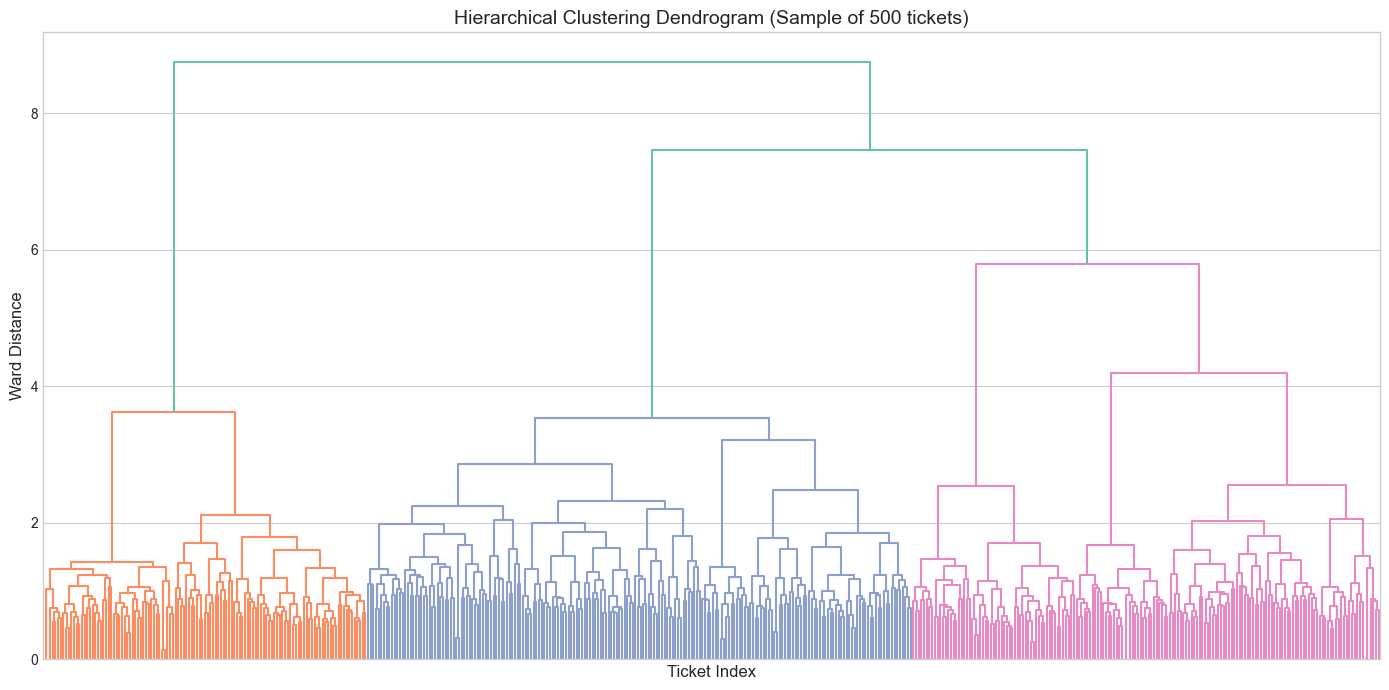

In [ ]:
print("\n" + "="*70)
print("Creating Dendrogram")
print("="*70)

# Sample for visualization
sample_size = 500
sample_indices = np.random.choice(len(df), sample_size, replace=False)
X_sample = X_embeddings[sample_indices]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Sample of 500 tickets)', 
          fontsize=14)
plt.xlabel('Ticket Index', fontsize=12)
plt.ylabel('Ward Distance', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_coherence(texts, labels):
    """
    Calculate coherence using top words per cluster.
    """
    tokenized_texts = [text.split() for text in texts]
    dictionary = Dictionary(tokenized_texts)
    
    cluster_topics = []
    for cluster_id in range(5):
        cluster_mask = labels == cluster_id
        cluster_texts = [tokenized_texts[i] for i, mask in enumerate(cluster_mask) if mask]
        
        word_freq = Counter()
        for text in cluster_texts:
            word_freq.update(text)
        
        top_words = [word for word, count in word_freq.most_common(10)]
        cluster_topics.append(top_words)
    
    cm = CoherenceModel(
        topics=cluster_topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    return cm.get_coherence()

print("\n" + "="*70)
print("Coherence Calculation")
print("="*70)

kmeans_coherence = calculate_coherence(
    df['trunc_processed_text'].tolist(),
    kmeans_labels
)

hac_coherence = calculate_coherence(
    df['trunc_processed_text'].tolist(),
    hac_labels
)

print(f"K-Means coherence: {kmeans_coherence:.4f}")
print(f"HAC coherence: {hac_coherence:.4f}")


Coherence Calculation
K-Means coherence: 0.7304
HAC coherence: 0.7511


In [ ]:
true_labels = df['type']  # Or whatever the column is called

# For K-Means
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

print(f"K-Means ARI: {kmeans_ari:.4f}")
print(f"K-Means NMI: {kmeans_nmi:.4f}")

# For HAC
hac_ari = adjusted_rand_score(true_labels, hac_labels)
hac_nmi = normalized_mutual_info_score(true_labels, hac_labels)

print(f"HAC ARI: {hac_ari:.4f}")
print(f"HAC NMI: {hac_nmi:.4f}")

K-Means ARI: 0.1982
K-Means NMI: 0.2066
HAC ARI: 0.2354
HAC NMI: 0.2519


In [ ]:
results_summary = pd.DataFrame({
    'Method': ['K-Means', 'HAC'],
    'Silhouette': [kmeans_silhouette, hac_silhouette],
    'ARI': [kmeans_ari, hac_ari],  # ADD THIS
    'NMI': [kmeans_nmi, hac_nmi],  # ADD THIS
    'Coherence': [kmeans_coherence, hac_coherence],
    'k': [5, 5],
    'seed': [42, '-']
})

print("\n" + "="*70)
print("Embeddings Clustering Results")
print("="*70)
print(results_summary.to_string(index=False))


Embeddings Clustering Results
 Method  Silhouette      ARI      NMI  Coherence  k seed
K-Means    0.121440 0.198222 0.206634   0.730414  5   42
    HAC    0.096987 0.235407 0.251868   0.751061  5    -



Generating Silhouette Plots


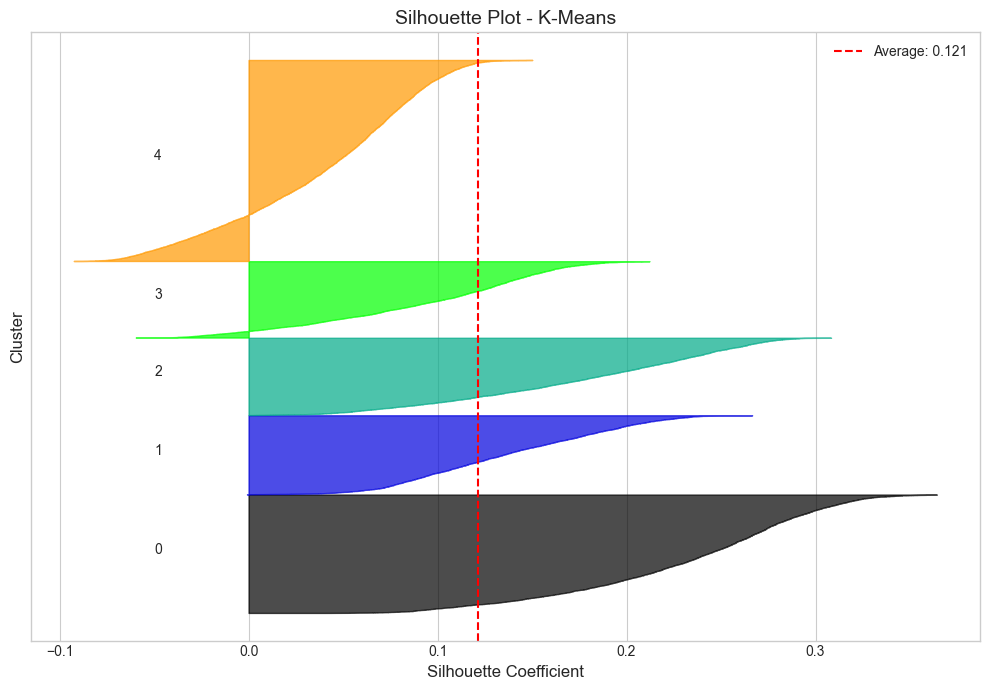

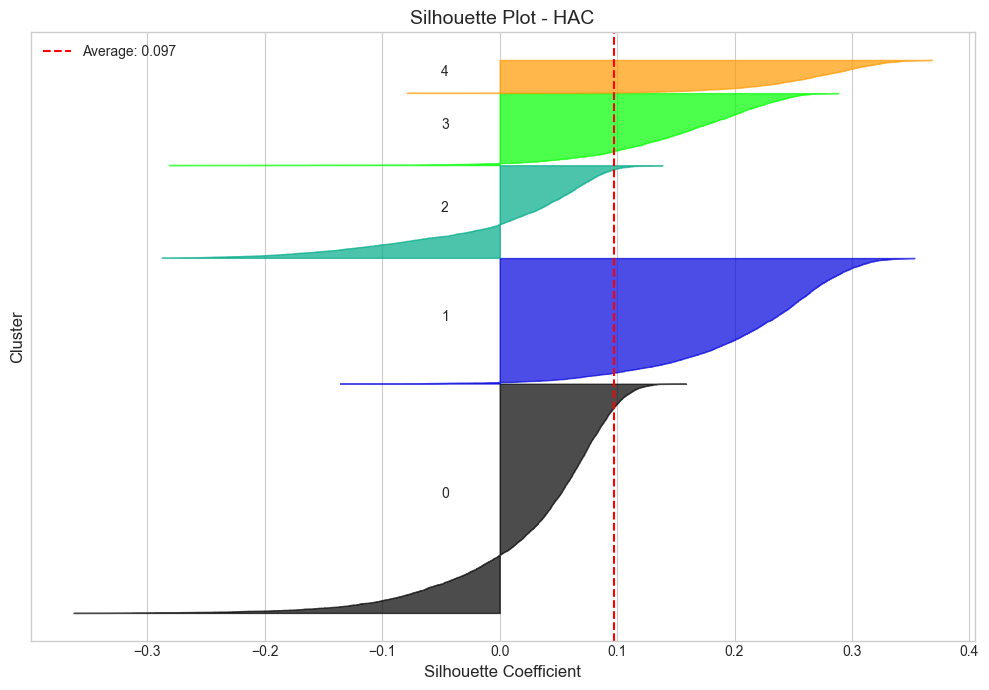

In [ ]:
from matplotlib import cm

def plot_silhouette_analysis(X, labels, method_name):
    """
    Create silhouette plot for cluster analysis.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)
    
    y_lower = 10
    for i in range(5):
        cluster_silhouette_values = sample_silhouette_values[labels == i]
        cluster_silhouette_values.sort()
        
        size_cluster = cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster
        
        color = cm.nipy_spectral(float(i) / 5)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Plot - {method_name}', fontsize=14)
    ax.set_xlabel('Silhouette Coefficient', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", 
               label=f'Average: {silhouette_avg:.3f}')
    ax.legend()
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("Generating Silhouette Plots")
print("="*70)

plot_silhouette_analysis(X_embeddings, kmeans_labels, "K-Means")
plot_silhouette_analysis(X_embeddings, hac_labels, "HAC")


In [ ]:
def analyze_clusters(texts, labels, method_name):
    """
    Extract cluster statistics and top words.
    """
    print(f"\n{'='*70}")
    print(f"{method_name} - Cluster Analysis")
    print(f"{'='*70}")
    
    for cluster_id in range(5):
        cluster_mask = labels == cluster_id
        cluster_texts = [texts[i] for i, mask in enumerate(cluster_mask) if mask]
        
        # Word frequency
        word_freq = Counter()
        for text in cluster_texts:
            word_freq.update(text.split())
        
        top_words = [word for word, count in word_freq.most_common(15)]
        
        size = len(cluster_texts)
        percentage = (size / len(texts)) * 100
        
        print(f"\nCluster {cluster_id}:")
        print(f"  Size: {size:,} tickets ({percentage:.1f}%)")
        print(f"  Top words: {', '.join(top_words[:10])}")
    
    return

# Analyze K-Means clusters
analyze_clusters(df['trunc_processed_text'].tolist(), kmeans_labels, "K-Means")


K-Means - Cluster Analysis

Cluster 0:
  Size: 5,985 tickets (21.4%)
  Top words: data, security, medical, access, information, breach, hospital, system, update, issue

Cluster 1:
  Size: 3,999 tickets (14.3%)
  Top words: data, investment, analytics, tool, issue, appreciate, provide, decision, optimize, make

Cluster 2:
  Size: 3,910 tickets (14.0%)
  Top words: digital, strategy, brand, market, growth, campaign, engagement, enhance, appreciate, target

Cluster 3:
  Size: 3,861 tickets (13.8%)
  Top words: integration, project, management, provide, detail, saas, information, appreciate, integrate, platform

Cluster 4:
  Size: 10,164 tickets (36.4%)
  Top words: issue, problem, resolve, update, restart, software, data, assistance, appreciate, recent


In [ ]:

analyze_clusters(df['trunc_processed_text'].tolist(), hac_labels, "HAC")


HAC - Cluster Analysis

Cluster 0:
  Size: 11,589 tickets (41.5%)
  Top words: issue, problem, resolve, update, data, software, restart, assistance, appreciate, recent

Cluster 1:
  Size: 6,345 tickets (22.7%)
  Top words: data, security, medical, access, information, breach, issue, hospital, update, system

Cluster 2:
  Size: 4,682 tickets (16.8%)
  Top words: integration, project, provide, management, detail, appreciate, information, saas, integrate, platform

Cluster 3:
  Size: 3,637 tickets (13.0%)
  Top words: digital, strategy, brand, market, growth, campaign, engagement, enhance, target, appreciate

Cluster 4:
  Size: 1,666 tickets (6.0%)
  Top words: investment, data, analytics, tool, provide, decision, optimize, make, appreciate, inform


In [ ]:
def show_cluster_samples(df, labels, method_name):
    """
    Display sample tickets for each cluster.
    """
    print(f"\n{'='*70}")
    print(f"{method_name} - Sample Tickets")
    print(f"{'='*70}")
    
    for cluster_id in range(5):
        cluster_tickets = df[labels == cluster_id]['trunc_processed_text']
        print(f"\nCluster {cluster_id} samples:")
        
        for i, ticket in enumerate(cluster_tickets.head(2)):
            print(f"  {i+1}. {ticket[:120]}...")

# Show samples for K-Means
show_cluster_samples(df, kmeans_labels, "K-Means")

# Show samples for HAC
show_cluster_samples(df, hac_labels, "HAC")


K-Means - Sample Tickets

Cluster 0 samples:
  1. reach good health seek comprehensive instruction effectively integrate seagate expansion desktop tb drive healthcare sto...
  2. recently notify attempt unauthorized entry iot gadget raise significant worry security home network grateful immediate h...

Cluster 1 samples:
  1. reach request comprehensive detail optimize market workflow multiple department utilize advance analytics automation cen...
  2. reach write request improvement exist big data analytics infrastructure goal enhance advance machine learn model develop...

Cluster 2 samples:
  1. reach write request detail information market offering company currently consider new market approach strengthen brand v...
  2. reach write request detail overview service provide market firm organization currently examine option improve market cam...

Cluster 3 samples:
  1. reach reach request detail information capability smart home integration product list website potential aim develop

In [ ]:
print("\n" + "="*70)
print("Embeddings Clustering Analysis Complete")
print("="*70)

print("\nConfiguration:")
print(f"  Model: all-MiniLM-L6-v2")
print(f"  k: 5")
print(f"  seed: 42")
print(f"  Documents: {len(df):,}")

print("\nK-Means Results:")
print(f"  Silhouette: {kmeans_silhouette:.4f}")
print(f"  Coherence: {kmeans_coherence:.4f}")
print(f"  Inertia: {kmeans_inertia:.2f}")

print("\nHAC Results:")
print(f"  Silhouette: {hac_silhouette:.4f}")
print(f"  Coherence: {hac_coherence:.4f}")

print("\n" + "="*70)


Embeddings Clustering Analysis Complete

Configuration:
  Model: all-MiniLM-L6-v2
  k: 5
  seed: 42
  Documents: 27,919

K-Means Results:
  Silhouette: 0.1214
  Coherence: 0.7304
  Inertia: 15136.99

HAC Results:
  Silhouette: 0.0970
  Coherence: 0.7511



In [ ]:
# Save embeddings so axis1 notebook can load them instantly
import numpy as np
np.save('/Users/aanchala/Task4/data/embeddings_minilm.npy', X_embeddings)
print(f"Saved! Shape: {X_embeddings.shape}")

NameError: name 'X_embeddings' is not defined